In [17]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.preprocessing import label_binarize

CLASS_NAMES = ['Normal', 'Bacterial', 'Viral']
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cpu


In [18]:
def build_resnet101():
    model = models.resnet101(weights='IMAGENET1K_V1')

    for param in model.parameters():
        param.requires_grad = False

    for param in model.layer2.parameters():
        param.requires_grad = True
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True

    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.LayerNorm(512),
        nn.Dropout(0.4),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 3)
    )
    return model

print("ResNet101 architecture defined ✓")

ResNet101 architecture defined ✓


In [19]:
# Using Run 2 — change to run1 if preferred
RUN = 2
SEED_MAP = {1: 42, 2: 7, 3: 99, 4: 2024, 5: 13}
SEED = SEED_MAP[RUN]

# Load model
saved_model = build_resnet101().to(device)
saved_model.load_state_dict(torch.load(
    f'/content/drive/MyDrive/resnet101_run{RUN}.pth',
    map_location=device
))
saved_model.eval()
print(f"Model from Run {RUN} loaded ✓")

# Load predictions
y_pred_last  = np.load(f'/content/drive/MyDrive/resnet101_preds_run{RUN}.npy')
y_test_last  = np.load(f'/content/drive/MyDrive/resnet101_true_run{RUN}.npy')
y_probs_last = np.load(f'/content/drive/MyDrive/resnet101_probs_run{RUN}.npy')
print(f"Predictions from Run {RUN} loaded ✓")
print(f"Test samples: {len(y_test_last)}")

Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth


100%|██████████| 171M/171M [00:02<00:00, 79.9MB/s]


Model from Run 2 loaded ✓
Predictions from Run 2 loaded ✓
Test samples: 1172


In [20]:
df_results = pd.read_csv('/content/drive/MyDrive/resnet101_results.csv')
metrics    = ["Accuracy", "Precision", "Recall", "F1 Score"]

print("===== ResNet101 – Per Run Results =====")
print(df_results.to_string(index=False))

summary = pd.DataFrame({
    "Mean" : df_results[metrics].mean(),
    "Std"  : df_results[metrics].std(),
})
print("\n===== AVERAGE PERFORMANCE =====")
print(summary.round(4).to_string())

===== ResNet101 – Per Run Results =====
 Run  Accuracy  Precision   Recall  F1 Score
   1  0.828498   0.814658 0.828924  0.820670
   2  0.837031   0.829642 0.824161  0.824524

===== AVERAGE PERFORMANCE =====
             Mean     Std
Accuracy   0.8328  0.0060
Precision  0.8222  0.0106
Recall     0.8265  0.0034
F1 Score   0.8226  0.0027


In [21]:
DATASET_PATH = "/content/drive/MyDrive/chest_xray/chest_xray"

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

all_paths  = []
all_labels = []

for split in ['train', 'test', 'val']:
    normal_folder = os.path.join(DATASET_PATH, split, 'NORMAL')
    if os.path.exists(normal_folder):
        for fname in os.listdir(normal_folder):
            if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                all_paths.append(os.path.join(normal_folder, fname))
                all_labels.append(0)

for split in ['train', 'test', 'val']:
    pneumonia_folder = os.path.join(DATASET_PATH, split, 'PNEUMONIA')
    if os.path.exists(pneumonia_folder):
        for fname in os.listdir(pneumonia_folder):
            if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                fpath = os.path.join(pneumonia_folder, fname)
                if 'bacteria' in fname.lower():
                    all_paths.append(fpath)
                    all_labels.append(1)
                elif 'virus' in fname.lower():
                    all_paths.append(fpath)
                    all_labels.append(2)

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)

# Recreate same test split using the seed for selected run
_, X_test_last, _, _ = train_test_split(
    all_paths, all_labels,
    test_size=0.2, random_state=SEED,
    stratify=all_labels
)
print(f"Test set recreated with seed={SEED}: {len(X_test_last)} images ✓")

Test set recreated with seed=7: 1172 images ✓


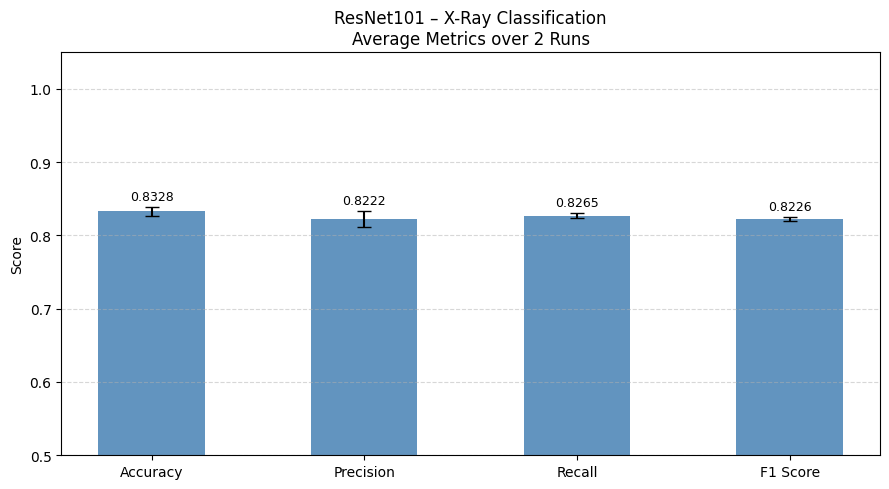

In [22]:
avg = df_results[metrics].mean()
std = df_results[metrics].std()

x     = np.arange(len(metrics))
width = 0.5

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(x, avg, width, yerr=std, color='steelblue', capsize=5, alpha=0.85)
ax.set_ylabel('Score')
ax.set_title(f'ResNet101 – X-Ray Classification\nAverage Metrics over {len(df_results)} Runs')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.05)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

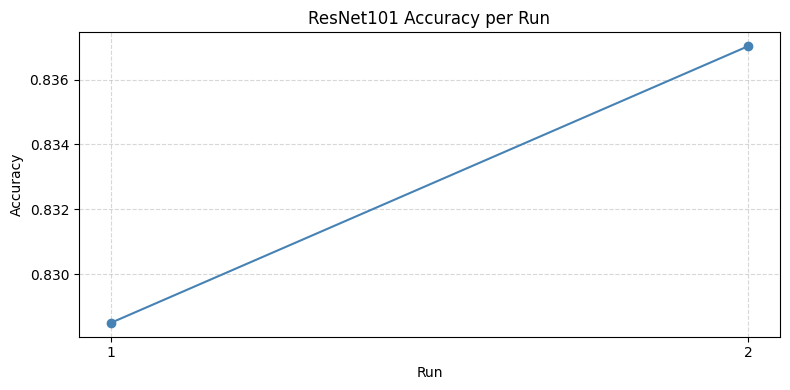

In [23]:
plt.figure(figsize=(8, 4))
plt.plot(df_results["Run"], df_results["Accuracy"], 'o-', color='steelblue')
plt.xlabel('Run'); plt.ylabel('Accuracy')
plt.title('ResNet101 Accuracy per Run')
plt.xticks(df_results["Run"])
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

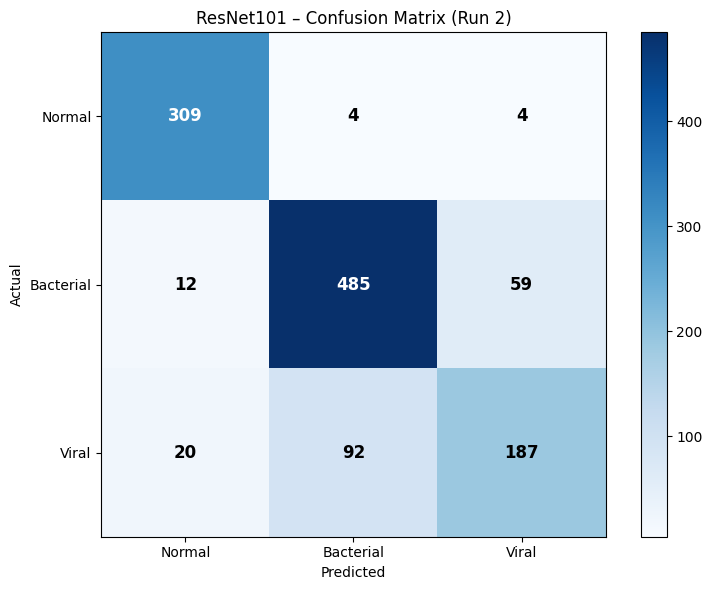

In [24]:
cm  = confusion_matrix(y_test_last, y_pred_last)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black',
                fontsize=12, fontweight='bold')
ax.set_title(f'ResNet101 – Confusion Matrix (Run {RUN})')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

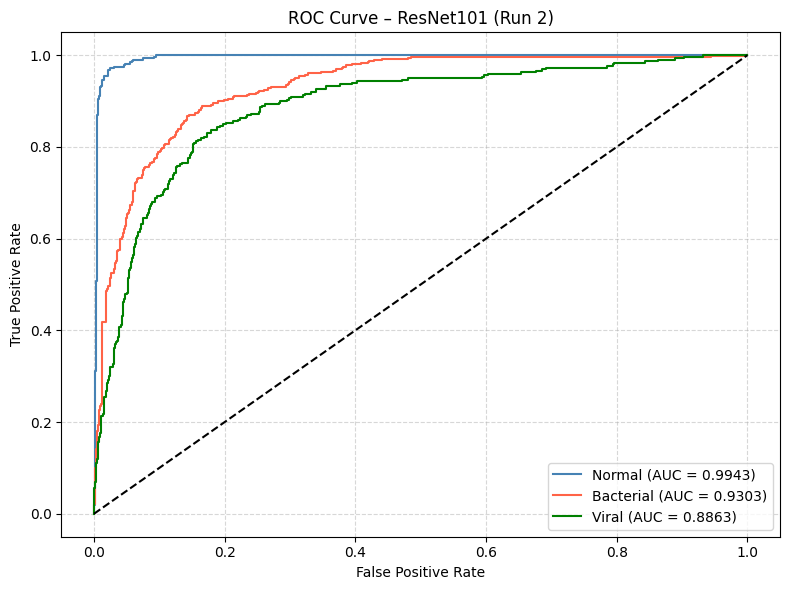

In [25]:
y_true_bin = label_binarize(y_test_last, classes=[0, 1, 2])
colors     = ['steelblue', 'tomato', 'green']

plt.figure(figsize=(8, 6))
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_last[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color,
             label=f'{cls_name} (AUC = {roc_auc:.4f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve – ResNet101 (Run {RUN})')
plt.legend(); plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [26]:
print(f"===== ResNet101 – Classification Report (Run {RUN}) =====")
print(classification_report(y_test_last, y_pred_last,
                             target_names=CLASS_NAMES))

===== ResNet101 – Classification Report (Run 2) =====
              precision    recall  f1-score   support

      Normal       0.91      0.97      0.94       317
   Bacterial       0.83      0.87      0.85       556
       Viral       0.75      0.63      0.68       299

    accuracy                           0.84      1172
   macro avg       0.83      0.82      0.82      1172
weighted avg       0.83      0.84      0.83      1172



In [27]:
class GradCAM:
    def __init__(self, model):
        self.model       = model
        self.gradients   = None
        self.activations = None

        model.layer4[-1].register_forward_hook(self._save_activations)
        model.layer4[-1].register_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        self.model.eval()
        output = self.model(input_tensor)

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = (weights * self.activations).sum(dim=1).squeeze()
        cam     = torch.relu(cam)
        cam     = cam.cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

print("Grad-CAM class defined ✓")

Grad-CAM class defined ✓


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


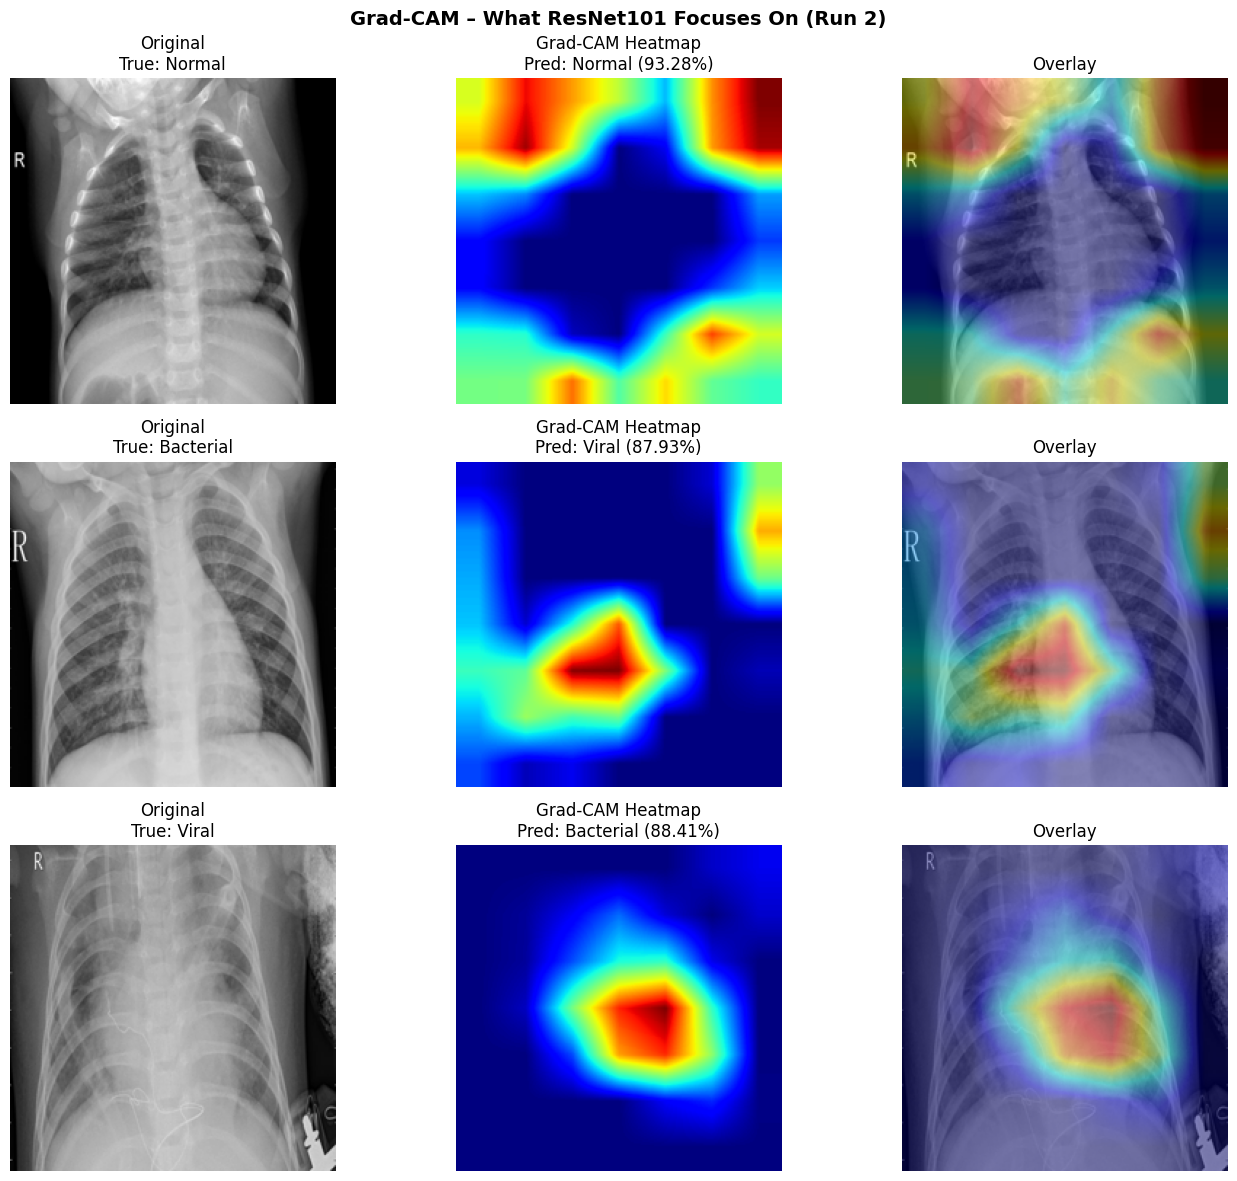

In [28]:
gradcam = GradCAM(saved_model)

# Pick one sample from each class
samples_to_show = []
for class_idx in range(3):
    idx = next(i for i, label in enumerate(y_test_last)
               if label == class_idx)
    samples_to_show.append((X_test_last[idx], class_idx))

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for row, (img_path, true_label) in enumerate(samples_to_show):
    orig_img = Image.open(img_path).convert('RGB')
    orig_img = orig_img.resize((224, 224))
    orig_arr = np.array(orig_img)

    input_tensor = test_transform(orig_img).unsqueeze(0).to(device)

    with torch.no_grad():
        output     = saved_model(input_tensor)
        pred_label = torch.argmax(output).item()
        confidence = torch.softmax(output, dim=1)[0][pred_label].item()

    cam         = gradcam.generate(input_tensor, pred_label)
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized),
                                    cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay     = (0.6 * orig_arr + 0.4 * heatmap).astype(np.uint8)

    axes[row, 0].imshow(orig_arr)
    axes[row, 0].set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam_resized, cmap='jet')
    axes[row, 1].set_title(f'Grad-CAM Heatmap\n'
                            f'Pred: {CLASS_NAMES[pred_label]}'
                            f' ({confidence:.2%})')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title('Overlay')
    axes[row, 2].axis('off')

plt.suptitle(f'Grad-CAM – What ResNet101 Focuses On (Run {RUN})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()